# Games, Best Responses, and Nash Equilibrium

Alex Ronczewski  
2026-07-16

## Outline

### Prerequisites

-   ECON 221, or any first course that introduced games, dominance, and
    Nash equilibrium. Every concept is re-taught here, so it’s not
    strictly necessary, but nice to have.
-   Basic Python and `numpy` at the COMET-intermediate level.
-   You do **not** need any machine-learning background. The “learning”
    our players do is built from scratch.

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Describe a simultaneous-move game in **normal form**: players,
    actions, and payoffs.
2.  Encode a two-player game as a pair of payoff matrices and load it
    into `nashpy`.
3.  Identify **strictly dominant** and **strictly dominated**
    strategies, and solve a game by **iterated elimination** of
    dominated strategies.
4.  Compute a player’s **best response** to any action of the opponent.
5.  Define a **pure-strategy Nash equilibrium** as a profile of mutual
    best responses, and find every pure equilibrium of a game in code.
6.  Simulate **best-response dynamics**, where algorithms repeatedly
    react to each other’s last move, and explain why the process settles
    in some games and cycles forever in others.

In [1]:
#Load our libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import nashpy as nash

## 1. When the players are algorithms

The game theory you learn about in ECON 221 is about people (usually
called agents). Two rational players study a payoff table, do some math
and arrive at an equilibrium. We keep this logic, but adapt it towards
algorithms and machines. When you buy something online, the price was
probably set by a repricing algorithm watching its competitors’ prices.
The ads you see were sold in auctions where the bidders are algorithms.
Recommender systems, trading systems, and more recently LLM agents all
play games against each other, at a speed and scale no human player
could match.

Moving away from human agents into machines changes a lot of things.
Rational people can be assumed to reason out the equilibrium before
playing. An algorithm follows whatever rule it was given in its code: it
observes, it reacts, it updates. So alongside the classical question in
Game Theory of, *what is the equilibrium of this game?*, this stream
asks a second one: *what do interacting algorithms converge to?*
Sometimes the two answers agree, and when they do, the equilibrium
prediction is unchanged. Sometimes they disagree, and the disagreements
turn out to be where the interesting findings are.

This notebook stays at the ECON 221 level and sets up both sides. First
the human side: encoding a game, dominance, best responses, and pure
Nash equilibrium. Then the algorithmic side, with the simplest player we
can possibly write: one that only reacts to its opponent’s last move. We
can then look at where that player converges to, and where it never
converges and keeps looping.

### 1.1 A game in normal form

This is the game we will return to often in this stream. Two online
retailers sell the same product, and each has handed its pricing to an
algorithm. Every morning both algorithms post a price, **High** or
**Low**, at the same time and without seeing each other’s choice. If
both post High, the firms split the market at a comfortable margin. If
one undercuts, the discounter takes most of the market and the expensive
firm keeps only a loyal remnant. If both post Low, they split the market
again, at a price-war margin.

A simultaneous-move game in **normal form** consists of three
ingredients:

-   **Players.** Who is playing: here the two firms, (more accurately
    their algorithms), $i = 1, 2$.
-   **Actions.** What each player can do: here
    $A_1 = A_2 = \{\text{High}, \text{Low}\}$.
-   **Payoffs.** What each player gets for every combination of actions:
    $u_i(a_1, a_2)$, here daily profit.

This is the associated payoff table for this game:

|                  | Firm 2: High | Firm 2: Low |
|------------------|--------------|-------------|
| **Firm 1: High** | 10, 10       | 2, 12       |
| **Firm 1: Low**  | 12, 2        | 4, 4        |

The first number in each cell is firm 1’s payoff, the second is firm
2’s. Firm 1 picks the row, firm 2 picks the column.

To work with this in code we use `nashpy`, a Python library for
two-player games. It wants one payoff matrix per player: firm 1’s matrix
`A` holds the first number of every cell, and firm 2’s matrix `B` holds
the second. Because the game is symmetric, `B` is the transpose of `A`.

In [2]:
A = np.array([[10, 2],
              [12, 4]])   # firm 1's payoffs: rows are its price (High, Low)
B = A.T                   # firm 2's payoffs: same game for the other player

prices = ["High", "Low"]
pricing_game = nash.Game(A, B)
print(pricing_game)

Bi matrix game with payoff matrices:

Row player:
[[10  2]
 [12  4]]

Column player:
[[10 12]
 [ 2  4]]

The printout shows the two matrices we typed: the row player’s payoffs
and the column player’s payoffs. From here on, every game in this stream
enters the computer in exactly this form, one payoff array per player.

## 2. Dominance

Now the important question, what should firm 1’s algorithm post? Let’s
look at the rival’s two possible prices one at a time. If firm 2 posts
High, firm 1 earns 12 from Low against 10 from High. If firm 2 posts
Low, firm 1 earns 4 from Low against 2 from High. Low wins in both
cases, so firm 1 does not need to know, guess, or predict anything about
its rival in order to act.

That situation has a name. An action $a_i$ **strictly dominates** an
action $a_i'$ if it pays strictly more against every possible action of
the opponent:

$$
u_i(a_i, a_{-i}) > u_i(a_i', a_{-i}) \quad \text{for every } a_{-i}.
$$

The subscript $-i$ is game theory shorthand for “the other player”. An
action that is strictly dominated can be ignored outright: no belief
about the opponent could ever make it the right choice. Checking
dominance in code is one comparison of rows (for firm 1) or columns (for
firm 2):

In [3]:
print("Firm 1: Low beats High against every rival price:", bool((A[1] > A[0]).all()))
print("Firm 2: Low beats High against every rival price:", bool((B[:, 1] > B[:, 0]).all()))

Firm 1: Low beats High against every rival price: True
Firm 2: Low beats High against every rival price: True

Both firms have Low as a strictly dominant action, so the game has a
clean prediction: **(Low, Low)**, each firm earning 4, every day. Now
look at (High, High), where each firm would earn 10. Both firms would
prefer this outcome, but it is impossible, because against a
High-pricing rival the best move is to undercut (Low). You most likely
have learned this game: it is the **prisoner’s dilemma**.

### 2.1 Three prices and iterated elimination

Real repricers choose from more than two price points, so let us add a
third. The firms can now post **High**, **Medium**, or **Low**, where
Low is an extreme discount with almost no margin left for the firm. As
before, the cheaper firm takes most of the market, equal prices split
it, and an overpriced firm keeps a small base of loyal customers. Our
payoff matrix is now:

|                    | Firm 2: High | Firm 2: Medium | Firm 2: Low |
|--------------------|--------------|----------------|-------------|
| **Firm 1: High**   | 50, 50       | 20, 60         | 20, 20      |
| **Firm 1: Medium** | 60, 20       | 30, 30         | 12, 20      |
| **Firm 1: Low**    | 20, 20       | 20, 12         | 10, 10      |

Is any strategy dominant now? We check every pair of actions. The game
is symmetric, so whatever holds for firm 1 holds for firm 2 as well.

In [4]:
three_prices = ["High", "Medium", "Low"]
A3 = np.array([[50, 20, 20],
               [60, 30, 12],
               [20, 20, 10]])

for i in range(3):
    for j in range(3):
        if i != j and (A3[i] > A3[j]).all():
            print(f"{three_prices[i]} strictly dominates {three_prices[j]}")

Medium strictly dominates Low

Only one relation survives: Medium strictly dominates Low. The
aggressive discount buys the whole market and destroys the margin doing
it, so it loses to Medium no matter what the rival posts. But no action
is dominant anymore: Medium is the best reply to High and to Medium, yet
against a Low rival, High earns 20 while Medium earns only 12.

So we cannot name firm 1’s best action just yet. Something is still
true, though: *no rational firm will ever post Low*. And firm 1 knows
firm 2 is rational, so firm 1 can plan as if Low were simply missing
from the rival’s set of possible actions. Delete the Low row and the Low
column, and inspect the game that remains.

In [5]:
A3_reduced = A3[:2, :2]   # drop the Low row and the Low column

for i in range(2):
    for j in range(2):
        if i != j and (A3_reduced[i] > A3_reduced[j]).all():
            print(f"after eliminating Low: {three_prices[i]} strictly dominates {three_prices[j]}")

after eliminating Low: Medium strictly dominates High

In the reduced game Medium strictly dominates High, so both firms play
Medium and the game is solved. This two-step argument is **iterated
elimination of strictly dominated strategies**. Notice how each deletion
leans on one more layer of knowledge: round one only required each firm
to be rational, while round two required each firm to *know that the
other is rational*. A third round would require “I know that you know
that I know”, and so on down the chain. Notice also what did and did not
change from the 2x2 version: the race to the bottom stopped one step
early, at (Medium, Medium) and payoffs of 30, yet both firms would still
prefer (High, High) at 50. The prisoner’s dilemma lesson survives.

## 3. Best responses

Two platforms are deciding whether to move their recommendation systems
onto a shared industry **data standard**. If both adopt it, their
systems interoperate and both gain a lot. Adopting alone is expensive
and useless: you rebuilt your data pipeline and there is nobody for it
to connect with. Keeping the **legacy** setup is safe either way.

|                    | Firm 2: Adopt | Firm 2: Legacy |
|--------------------|---------------|----------------|
| **Firm 1: Adopt**  | 4, 4          | 0, 3           |
| **Firm 1: Legacy** | 3, 0          | 3, 3           |

Run the dominance check in your head. If the rival adopts, Adopt pays 4
against Legacy’s 3. If the rival stays on Legacy, Adopt pays 0 against
Legacy’s 3. Each action is best against something, so nothing is
dominated and elimination gets nowhere. (You may recognize this payoff
pattern from ECON 221: it is **stag hunt**.)

What we can still say is conditional: *given* the rival’s choice, one
action is best. That object is the **best response**:

$$
BR_i(a_{-i}) = \arg\max_{a_i \in A_i} u_i(a_i, a_{-i}),
$$

the action that maximizes player $i$’s payoff against a fixed action of
the opponent. In code a best response is one `argmax` over a row or
column of the payoff matrix, and it is the single most reused idea in
this stream: the simulator later in this notebook, the belief learner of
Notebook 2, and the Q-learners of Notebook 4 are all elaborations of
this `argmax`.

In [6]:
S = np.array([[4, 0],
              [3, 3]])
standards = ["Adopt", "Legacy"]

def br_row(A, col):
    return int(np.argmax(A[:, col]))

def br_col(B, row):
    return int(np.argmax(B[row, :]))

for j, rival in enumerate(standards):
    print(f"rival plays {rival:6} -> firm 1's best response: {standards[br_row(S, j)]}")

rival plays Adopt  -> firm 1's best response: Adopt
rival plays Legacy -> firm 1's best response: Legacy

The table reads: match your rival. Against Adopt, adopt; against Legacy,
stay on Legacy. This is what a **coordination** problem looks like, and
it leaves the central question of our stream open, because “match the
rival” does not say which action the pair will end up matched on. Before
answering that, it helps to *see* the structure of both games we have
met so far.

### 3.1 Marking best responses

The diagram below marks best responses directly on each payoff table,
the way you did it in ECON 221. In each column, we underline firm 1’s
best-response payoff, the biggest first number in that column. In each
row, we underline firm 2’s best-response payoff, the biggest second
number in that row. A cell where *both* payoffs end up underlined is
shaded green: both players are best responding there, so nobody wants to
move.

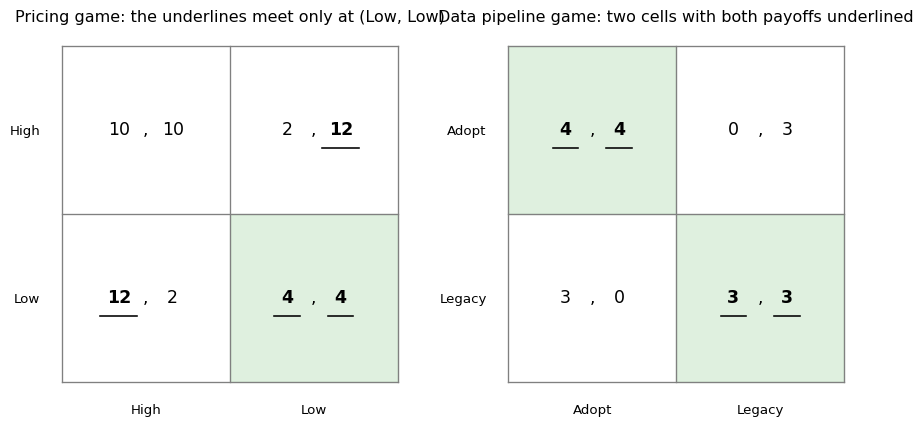

In [7]:
def draw_best_responses(A, B, actions, title, ax):
    for i in range(2):
        for j in range(2):
            br1 = A[i, j] == A[:, j].max()   # firm 1's best payoff in this column
            br2 = B[i, j] == B[i, :].max()   # firm 2's best payoff in this row
            y = 1 - i
            for payoff, x, is_br in [(A[i, j], j - 0.16, br1),
                                     (B[i, j], j + 0.16, br2)]:
                s = str(payoff)
                ax.text(x, y, s, ha="center", va="center", fontsize=13,
                        fontweight="bold" if is_br else "normal")
                if is_br:
                    half = 0.04 + 0.035 * len(s)
                    ax.plot([x - half, x + half], [y - 0.11, y - 0.11],
                            color="black", linewidth=1.2)
            ax.text(j, y, ",", ha="center", va="center", fontsize=13)
            if br1 and br2:
                ax.add_patch(plt.Rectangle((j - 0.5, 0.5 - i), 1, 1,
                                           color="tab:green", alpha=0.15))
    for edge in [-0.5, 0.5, 1.5]:
        ax.plot([edge, edge], [-0.5, 1.5], color="grey", linewidth=1)
        ax.plot([-0.5, 1.5], [edge, edge], color="grey", linewidth=1)
    ax.set_xticks([0, 1], actions)
    ax.set_yticks([1, 0], actions)
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(-0.6, 1.6)
    ax.set_aspect("equal")
    ax.set_frame_on(False)
    ax.tick_params(length=0)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
draw_best_responses(A, B, prices, "Pricing game: the underlines meet only at (Low, Low)", axes[0])
draw_best_responses(S, S.T, standards, "Data pipeline game: two cells with both payoffs underlined", axes[1])
plt.show()

On the left matrix, dominance is visible: firm 1’s underline sits in the
Low row of both columns and firm 2’s sits in the Low column of both
rows, so the only cell with two underlines is (Low, Low). On the right,
two cells collect both underlines, (Adopt, Adopt) and (Legacy, Legacy).
In each of them both players are best responding at the same time. Cells
like that are the subject of the most important definition in game
theory.

## 4. Nash equilibrium

A **Nash equilibrium** is a profile of actions, one per player, in which
every player’s action is a best response to what the others are doing.
No player can raise their own payoff by changing their action alone. For
two players, $(a_1^*, a_2^*)$ is a Nash equilibrium if

$$
u_1(a_1^*, a_2^*) \ge u_1(a_1, a_2^*) \quad \text{and} \quad u_2(a_1^*, a_2^*) \ge u_2(a_1^*, a_2) \quad \text{for all } a_1, a_2.
$$

> **Nash equilibrium is mutual best response**
>
> The definition has two readings.
>
> As a *solution concept*: every player is best responding to every
> other, so the profile is internally consistent, and nobody regrets
> their choice once the choices are revealed.
>
> As a *rest point*: if play somehow arrives at a Nash equilibrium, then
> no player who can only change their own action has a reason to move,
> so play stays there. Equilibria are the places where adjustment stops.
> This reading turns equilibrium into something a simulation can search
> for, and it is how algorithms, which never “solve” anything, can end
> up at one anyway. This is the definition this stream leans on more.

Finding the pure equilibria in code is a direct translation of the
underline diagram: visit every cell, and keep the ones where both
players are best responding at the same time.

In [8]:
def pure_equilibria(A, B, actions):
    found = []
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            if A[i, j] == A[:, j].max() and B[i, j] == B[i, :].max():
                found.append((actions[i], actions[j]))
    return found

print("Pricing game:  ", pure_equilibria(A, B, prices))
print("Data pipeline game:", pure_equilibria(S, S.T, standards))

Pricing game:   [('Low', 'Low')]
Data pipeline game: [('Adopt', 'Adopt'), ('Legacy', 'Legacy')]

The pricing game has exactly one equilibrium, (Low, Low), the doubly
underlined cell from the diagram. The data pipeline game has two, the
shaded cells: both firms on Adopt, or both firms on Legacy. Note that
(Legacy, Legacy) qualifies even though (Adopt, Adopt) pays more for
everyone. Equilibrium certifies the absence of profitable *individual*
deviations and says nothing about overall joint-quality. This is
important to keep in mind: an equilibrium does not necessarily imply
that this is a “good” or best outcome.

A game with two equilibria left us unable to say which one will happen.
The next game is worse: it has none at all.

### 4.1 A game with no pure equilibrium

A platform’s **fraud detector** is playing against a **scalper bot**.
Each round the bot attacks one of two sales channels, A or B, and the
detector concentrates its screening on one of the two. If the detector
picks the channel the bot attacked, the bot is caught: the detector
stops it and the bot loses. If it picks the wrong channel, the bot slips
through and scores.

|                         | Bot: Channel A | Bot: Channel B |
|-------------------------|----------------|----------------|
| **Detector: Channel A** | 1, -1          | -1, 1          |
| **Detector: Channel B** | -1, 1          | 1, -1          |

You may have seen this structure under the name **matching pennies** or
**Penatly Kicks**. It is a game of pure conflict: whatever one side
wins, the other loses, so the two payoffs in every cell sum to zero.

In [9]:
M = np.array([[ 1, -1],
              [-1,  1]])
channels = ["Channel A", "Channel B"]
detection_game = nash.Game(M, -M)
print(detection_game)

Zero sum game with payoff matrices:

Row player:
[[ 1 -1]
 [-1  1]]

Column player:
[[-1  1]
 [ 1 -1]]

Now we mark the best responses.

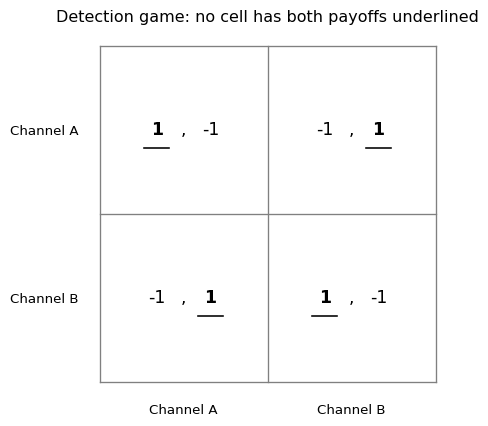

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))
draw_best_responses(M, -M, channels, "Detection game: no cell has both payoffs underlined", ax)
plt.show()

No cell is shaded, and you can see why. The detector wants to land on
the same channel as the bot, the bot wants the opposite, so in every
cell exactly one player is best responding and the other regrets its
choice. Follow the underlines around the table and they chase each other
in a circle: whichever cell you stand in, one player wants to move to
the next. Our finder confirms it:

In [11]:
print("Detection game:", pure_equilibria(M, -M, channels))

Detection game: []

An empty list: **the detection game has no pure Nash equilibrium**. No
profile of actions is stable, because in every cell somebody’s best move
is elsewhere. That is also how you would actually want to run a fraud
detector, since screening the same channel every day is an open
invitation to attack the other one.

## 5. Letting the algorithms play

Everything so far has been the analyst’s (human agents) view. We stood
outside each game, looked at the whole payoff table at once, and
computed. Real pricing algorithms don’t work like that: they observe
what the rival did and react to it. So let us hand each player the most
basic algorithm we can write.

> Each period, one player revises its action, switching to its best
> response against the opponent’s most recent move. The two players take
> turns revising.

That is the whole algorithm. It has a memory exactly one move deep, no
model of its opponent, and no plan beyond the next move. This process is
called **best-response dynamics**, and our question is: does play driven
by this rule find the equilibria we computed from the outside?

In [12]:
def br_dynamics(A, B, start, revisions):
    a, b = start
    path = [(a, b)]
    for t in range(revisions):
        if t % 2 == 0:
            a = br_row(A, b)   # row player revises
        else:
            b = br_col(B, a)   # column player revises
        path.append((a, b))
    return path

def show_path(path, actions):
    return " -> ".join(f"({actions[a]}, {actions[b]})" for a, b in path)

path = br_dynamics(A, B, start=(0, 0), revisions=6)
print(show_path(path, prices))

(High, High) -> (Low, High) -> (Low, Low) -> (Low, Low) -> (Low, Low) -> (Low, Low) -> (Low, Low)

We started the pricing game from the best collective outcome, (High,
High). Firm 1 revises first and immediately undercuts. Firm 2 revises
next and follows. From then on nothing ever changes: at a Nash
equilibrium a revising player finds nothing to improve, which is the
rest-point reading of the callout above. Two revisions were enough to
fall from the cooperative outcome to the equilibrium.

Now the data pipeline game, which has two equilibria. We run the same
dynamics from two different starting positions and chart each run as a
timeline: one row per player, one column per revision, and the colour of
each cell is the action being played.

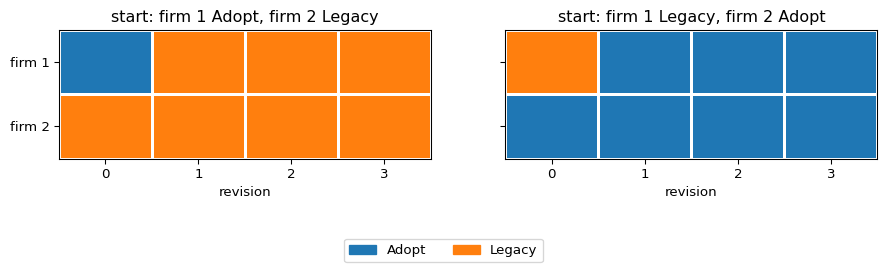

In [13]:
action_colors = ["tab:blue", "tab:orange"]

def plot_path(path, labels, title, ax):
    moves = np.array(path).T   # one row per player, one column per revision
    ax.pcolormesh(moves, cmap=ListedColormap(action_colors), vmin=0, vmax=1,
                  edgecolors="white", linewidth=2)
    ax.set_xticks(np.arange(len(path)) + 0.5, range(len(path)))
    ax.set_yticks([0.5, 1.5], labels)
    ax.set_ylim(2, 0)   # first player's row on top
    ax.set_xlabel("revision")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(11, 2.8), sharey=True)
for ax, start in zip(axes, [(0, 1), (1, 0)]):
    path = br_dynamics(S, S.T, start=start, revisions=3)
    plot_path(path, ["firm 1", "firm 2"],
              f"start: firm 1 {standards[start[0]]}, firm 2 {standards[start[1]]}", ax)
fig.legend(handles=[Patch(color=c, label=a) for c, a in zip(action_colors, standards)],
           ncols=2, loc="lower center")
fig.subplots_adjust(bottom=0.4)
plt.show()

Starting from (Adopt, Legacy), the pair locks into (Legacy, Legacy).
Starting from the mirror image, (Legacy, Adopt), it locks into (Adopt,
Adopt). Mechanically, the player that revises first abandons its own
position to match the rival’s last move, and after that neither has a
reason to move again. Which equilibrium a market ends up in is decided
by starting positions and the order of moves.

> **Self-test**
>
> In the left panel the algorithms locked into (Legacy, Legacy), where
> each firm earns 3 instead of the 4 available at (Adopt, Adopt). Did
> one of them malfunction?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> No. Check the definition: at (Legacy, Legacy), a firm that switched to
> Adopt alone would earn 0 instead of 3, so each firm is best responding
> and the profile is a Nash equilibrium. The pair is stuck in the worse
> of two equilibria, and escaping would require both firms to move at
> the same time, which the one-revision-at-a-time rule can never
> produce. The problem is coordination.
>
> </details>

One game left: the one with no pure equilibrium to rest at.

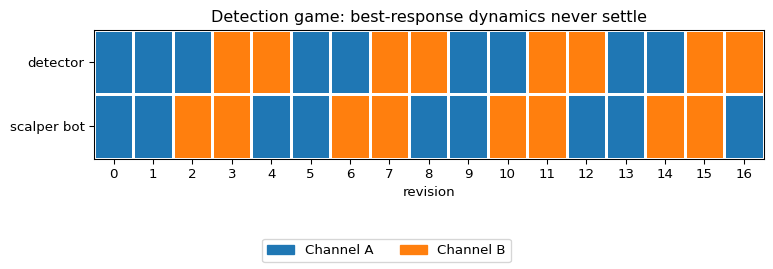

In [14]:
fig, ax = plt.subplots(figsize=(9, 2.8))
path = br_dynamics(M, -M, start=(0, 0), revisions=16)
plot_path(path, ["detector", "scalper bot"],
          "Detection game: best-response dynamics never settle", ax)
fig.legend(handles=[Patch(color=c, label=a) for c, a in zip(action_colors, channels)],
           ncols=2, loc="lower center")
fig.subplots_adjust(bottom=0.4)
plt.show()

In this game the chase never ends. The detector matches the bot, the bot
escapes to the other channel, the detector follows, the bot flees back,
and the pattern repeats every four revisions, forever. This is the
rotating pattern from section 4.1’s matrix traced out in real time.

Best-response dynamics stand still only at a profile where the revising
player has nothing to improve, whichever player that is, and a profile
where *both* players have nothing to improve is precisely a pure Nash
equilibrium. So:

-   If best-response dynamics settle, what they have settled on is a
    pure Nash equilibrium.
-   If a game has no pure Nash equilibrium, the dynamics have nowhere to
    settle, so it cycles.

Having a pure equilibrium makes convergence possible, and in the
well-behaved games of this notebook it happens, but larger games can
contain both an equilibrium and a cycle that never finds it. [Notebook
2](notebook_02_mixed_strategies_fictitious_play.qmd) shows us a famous
example.

## 6. Conclusion

In one notebook we went from encoding a game to watching algorithms play
it. The classical concepts from ECON 221 were a basis for our analysis:
dominance solved both pricing games, and best responses solved the ones
dominance could not. The simulation then added something the
pencil-and-paper toolkit cannot: a way to watch where play settles. A
pure Nash equilibrium is where best-response dynamics can rest. When a
game has several, history picks one. When it has none, the simplest
dynamics continue forever.

### References

-   Calvano, E., Calzolari, G., Denicolo, V., & Pastorello, S. (2020).
    *Artificial intelligence, algorithmic pricing, and collusion.*
    American Economic Review, 110(10), 3267-3297. The evidence behind
    this stream’s framing; Notebook 4 builds a small version of it.
-   Knight, V., & Campbell, J. (2018). *Nashpy: A Python library for the
    computation of Nash equilibria.* Journal of Open Source Software,
    3(30), 904. https://nashpy.readthedocs.io
-   Li, H. *ECON 221 and ECON 421 course outlines.* University of
    British Columbia.
    https://lihao.microeconomics.ca/li_content/econ221/outline.html
-   Osborne, M. J. (2004). *An Introduction to Game Theory.* Oxford
    University Press. (Chapters 2 and 3 cover everything in this
    notebook.)
-   Roughgarden, T. (2016). *Twenty Lectures on Algorithmic Game
    Theory.* Cambridge University Press.
    https://timroughgarden.org/notes.html
-   Shoham, Y., & Leyton-Brown, K. (2008). *Multiagent Systems:
    Algorithmic, Game-Theoretic, and Logical Foundations.* Cambridge
    University Press. https://www.masfoundations.org/mas.pdf